In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [82]:
# Load the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
df = pd.read_csv(url)
df.sample(5)

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
923,2014,ROLLS-ROYCE,GHOST EWB,FULL-SIZE,6.6,12,A8,Z,19.1,12.3,16.0,18,368
689,2014,MASERATI,GHIBLI AWD,MID-SIZE,3.0,6,AS8,Z,15.2,9.6,12.7,22,292
838,2014,NISSAN,ARMADA 4WD,SUV - STANDARD,5.6,8,A5,X,19.1,13.4,16.5,17,380
96,2014,BMW,435i xDRIVE COUPE,COMPACT,3.0,6,A8,Z,11.7,7.8,9.9,29,228
568,2014,JAGUAR,XKR-S COUPE,MINICOMPACT,5.0,8,AS6,Z,15.6,10.9,13.5,21,310


In [83]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [84]:
cdf = df[["ENGINESIZE", "CYLINDERS", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
cdf.sample(5)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
973,1.8,4,7.3,168
106,4.4,8,12.7,292
921,3.6,6,15.9,254
177,6.2,8,16.6,382
1063,3.2,6,11.5,264


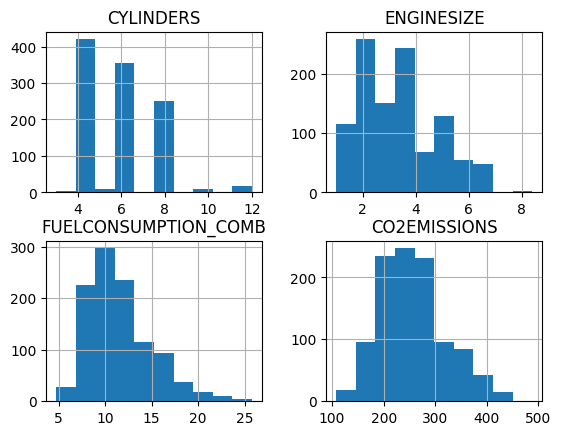

In [85]:
viz = cdf[["CYLINDERS", "ENGINESIZE", "FUELCONSUMPTION_COMB", "CO2EMISSIONS"]]
viz.hist()
plt.show()

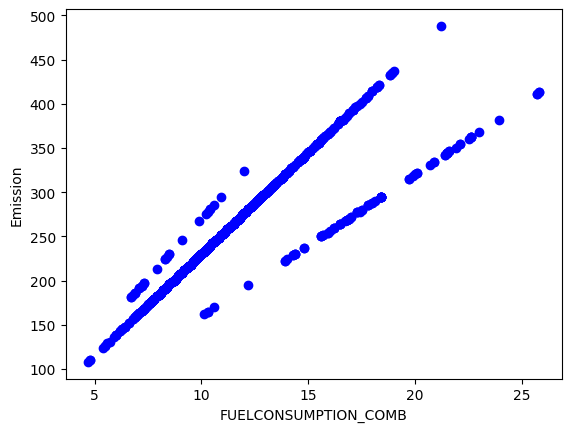

In [86]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

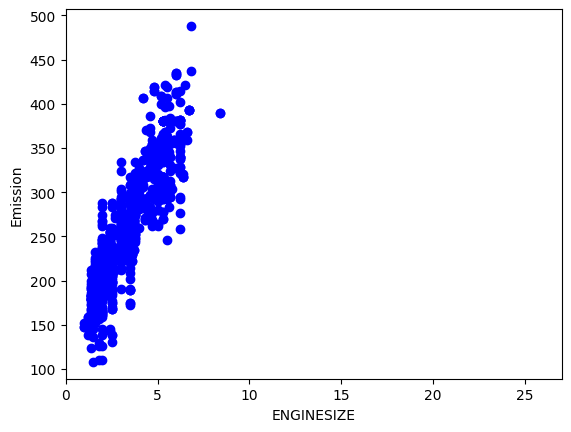

In [87]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("ENGINESIZE")
plt.ylabel("Emission")
plt.xlim(0,27)
plt.show()

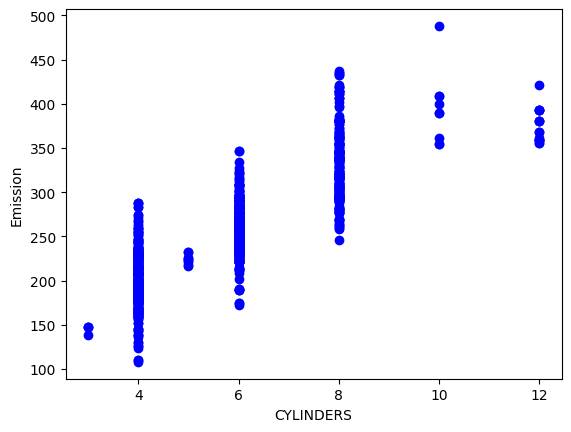

In [88]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("CYLINDERS")
plt.ylabel("Emission")
plt.show()

In [89]:
X = cdf.ENGINESIZE.to_numpy()
Y = cdf.CO2EMISSIONS.to_numpy()

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [91]:
type(X_train), np.shape(X_train)
X_train[0:5]

array([1.4, 4.4, 3. , 3. , 5.3])

In [92]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

X_train_reshaped = X_train.reshape(-1, 1)
print(X_train_reshaped[0:5])

regressor.fit(X_train_reshaped, Y_train)

print("Coefficients: ", regressor.coef_)
print("Intercept: ", regressor.intercept_)

[[1.4]
 [4.4]
 [3. ]
 [3. ]
 [5.3]]
Coefficients:  [38.99297872]
Intercept:  126.28970217408721


Text(0, 0.5, 'Emission')

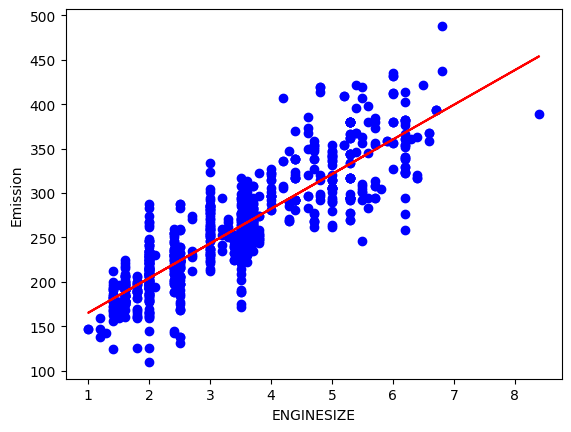

In [93]:
plt.scatter(X_train, Y_train, color='blue')
plt.plot(X_train, regressor.coef_[0]*X_train + regressor.intercept_, '-r')
plt.xlabel("ENGINESIZE")
plt.ylabel("Emission")

In [94]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

y_test = regressor.predict(X_test.reshape(-1,1))

print("Mean absolute error: %.2f" % mean_absolute_error(Y_test, y_test))
print("Mean squared error: %.2f" % mean_squared_error(Y_test, y_test))
print("Root mean squared error: %.2f" % root_mean_squared_error(Y_test, y_test))
print("R2-score: %.2f" % r2_score( Y_test, y_test) )

Mean absolute error: 24.10
Mean squared error: 985.94
Root mean squared error: 31.40
R2-score: 0.76


Text(0, 0.5, 'Emission')

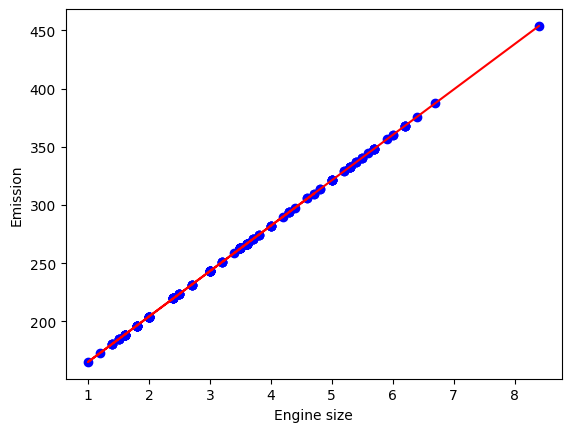

In [95]:
plt.scatter(X_test, y_test,  color='blue')
plt.plot(X_test, regressor.coef_ * X_test + regressor.intercept_, '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")

In [96]:
X = cdf.FUELCONSUMPTION_COMB.to_numpy()

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [98]:
regressor = LinearRegression()

X_train_reshaped = X_train.reshape(-1, 1)
print(X_train_reshaped[0:5])

regressor.fit(X_train_reshaped, Y_train)

print("Coefficients: ", regressor.coef_)
print("Intercept: ", regressor.intercept_)

[[ 7.8]
 [12.7]
 [ 9.9]
 [11.4]
 [16.5]]
Coefficients:  [16.18090078]
Intercept:  69.10302617988452


In [99]:
y_test = regressor.predict(X_test.reshape(-1,1))

In [100]:
print("Mean absolute error: %.2f" % mean_absolute_error(Y_test, y_test))
print("Mean squared error: %.2f" % mean_squared_error(Y_test, y_test))
print("Root mean squared error: %.2f" % root_mean_squared_error(Y_test, y_test))
print("R2-score: %.2f" % r2_score( Y_test, y_test) )

Mean absolute error: 20.44
Mean squared error: 797.43
Root mean squared error: 28.24
R2-score: 0.81


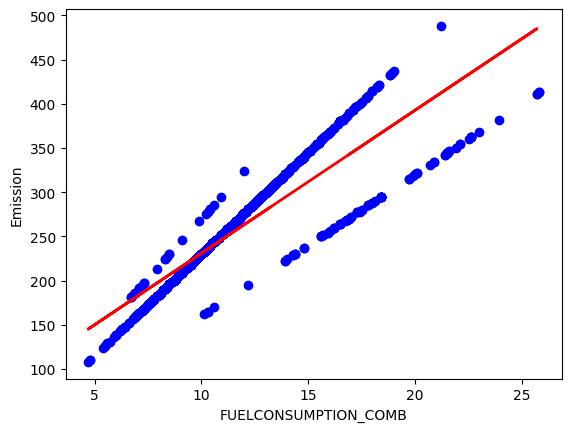

In [101]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.plot(X_test, y_test, color='red', linewidth=2)
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()